# Import Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle("../data/01_df_data_all.pkl")

# dependent variables

Analysis is broken up into Underwriting and Pricing. Underwriting uses action taken to derive target. Pricing is the column for interest rate.

## action taken

The categories we are interested in are approved, approved not accepted, and denied. Denied will become the outcome we want to explain. Observations with other outcomes are excluded from analysis.

In [3]:
df.groupby('action_taken').size()

action_taken
Approved not accepted                  2493
Denied                                15898
Incomplete                            14306
Originated                            94243
Preapproval approved not accepted      1082
Preapproval denied                     2746
Purchased                            212751
Withdrawn                             25475
dtype: int64

In [4]:
df['reg_uw'] = (df['action_taken']).isin(['Approved not accepted','Originated','Denied']).astype(int)

In [5]:
df.groupby(['reg_uw','action_taken']).size()

reg_uw  action_taken                     
0       Incomplete                            14306
        Preapproval approved not accepted      1082
        Preapproval denied                     2746
        Purchased                            212751
        Withdrawn                             25475
1       Approved not accepted                  2493
        Denied                                15898
        Originated                            94243
dtype: int64

In [6]:
df['denied'] = df['action_taken'].apply(lambda x: 1 if x == 'Denied' else 0)

In [7]:
df.groupby('denied').size()

denied
0    353096
1     15898
dtype: int64

## interest rate

For pricing we are interest in interest rate on the loan. This is the target in the OLS regression.

<Axes: >

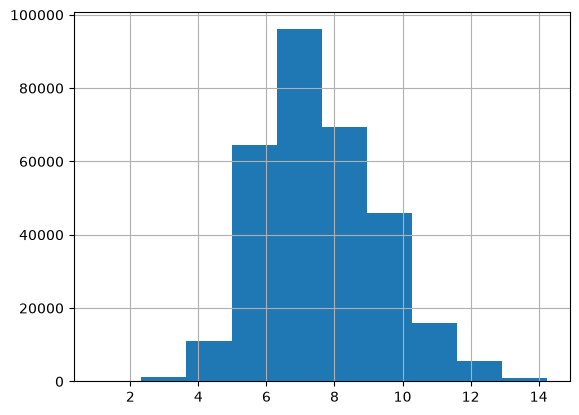

In [8]:
df.interest_rate.hist()

Checking which actions taken have interest rates assigned. If they are not assigned a rate they are excluded. I also exclude observations with actions that were already excluded in underwriting analysis.

In [9]:
df.groupby('action_taken').agg(
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,mi_rate,mu_rate,mx_rate
action_taken,,,
Approved not accepted,1.875,6.633895,10.240
Denied,NaN,NaN,NaN
Incomplete,NaN,NaN,NaN
Originated,1.000,6.483556,12.740
Preapproval approved not accepted,5.250,6.573542,8.625
Preapproval denied,NaN,NaN,NaN
Purchased,1.000,8.062459,14.250
Withdrawn,NaN,NaN,NaN


In [10]:
df['reg_price'] = (df['action_taken']).isin(['Approved not accepted','Originated']).astype(int)

# Segments

Some broad categories are taken as segments and excluded for the purpose of narrowing down the analysis. In this analysis I focus on personal loans for single applicants. In practice this becomes more complex when considering joint applicants and the protected basis of the application as a whole. 

## business or commercial

In [11]:

df.groupby('business_or_commercial_purpose').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
business_or_commercial_purpose,,,,,,
Business commercial,38977,1334,0.034225,1.25,7.152636,13.875
Not business commercial,330017,14564,0.044131,1.00,7.619235,14.250


In [12]:
df = df[df['business_or_commercial_purpose'].isin(['Not business commercial'])]

## Loan Type

Focusing on the three loan types below. Mainly because we need enough events (denied) to run the regression analysis. 

In [13]:
df.groupby('loan_type').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
loan_type,,,,,,
Conventional,315081,13090,0.041545,1.000,7.689357,14.250
FHA insured,11672,1276,0.109321,2.250,5.919339,9.500
USDA RHS FSA guaranteed,293,2,0.006826,2.625,4.402509,8.500
VA guaranteed,2971,196,0.065971,2.250,5.904677,8.375


In [14]:
df = df[df['loan_type'].isin(['Conventional','FHA insured','VA guaranteed'])]

## Loan Purpose

I focus on the following loan purposes to narrow down the interpretation of results. Categories like other and not applicable are ambiguous and its unclear what the consumer applied for.

In [15]:
df.groupby('loan_purpose').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
loan_purpose,,,,,,
Cash out refinance,142597,3045,0.021354,2.000,8.685150,14.25
Home improvement,7382,1305,0.176781,4.375,7.841923,10.24
Home purchase,119733,6708,0.056025,1.000,6.409366,13.86
Not applicable,4875,0,0.000000,1.000,5.807945,14.00
Other,13276,2092,0.157578,3.375,7.383253,12.74
Refinance,41861,1412,0.033731,1.750,6.926791,13.99


In [16]:
df = df[df['loan_purpose'].isin(['Cash out refinance','Home improvement','Home purchase','Refinance'])]
# df = df[df['loan_purpose'].isin(['Home purchase'])]

## single vs joint

Focusing on single applicants to simplify analysis and have clearer interpretation of results. This is done through the co applicant age value. Below is the data dictionary definition which indicates a value of 9999 means there is no co applicant.

"Bin the age reported into one of the ranged provided. Report 8888 if Age is NA or 9999 if No-Co-Applicant"

In [17]:
df.groupby("co_applicant_age").size()

co_applicant_age
25-34     18582
35-44     18737
45-54     11659
55-64     10258
65-74      7093
8888     152875
9999      87692
<25        1816
>74        2861
dtype: int64

In [18]:
df['co_applicant_age'].info()

<class 'pandas.Series'>
Index: 311573 entries, 0 to 368993
Series name: co_applicant_age
Non-Null Count   Dtype
--------------   -----
311573 non-null  str  
dtypes: str(1)
memory usage: 4.8 MB


In [19]:
df["joint_application"] = (
    (
    df["co_applicant_age"]
    .astype(str)
    .str.strip()
) != '9999'
).astype(int)

In [20]:
df["joint_application"].value_counts()

joint_application
1    223881
0     87692
Name: count, dtype: int64

In [21]:
df = df[df['joint_application'] == 0]

## Save Data

Saving data after making the exclusions to narrow down analysis and segments.

In [22]:
df.to_pickle('../data/02_df_data.pkl')

# Protected Basis Tests 

The analysis estimates the effect of being in a protected basis group when compared to a reference group. For this analysis I focus on race, gender, and age of applicant.

## Race

Race is determined through the applicant race 1 value. To be clear, there are several other columns 2-5 which make it possible to associate more than one race for a single applicant. For this analysis I focus on the _1 value. Additionally, I focus only on testing Black African American as the protected basis group and White as the reference.

In [23]:


df.groupby('applicant_race_1').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
applicant_race_1,,,,,,
American Indian Alaska Native,771,87,0.112840,2.750,6.386265,9.490
Asian,8706,679,0.077992,2.625,6.115499,9.740
Asian Indian,1479,121,0.081812,3.875,6.002844,9.240
Black African American,8815,1121,0.127170,2.500,6.452322,10.240
Chinese,457,47,0.102845,3.990,6.090755,9.240
Filipino,216,26,0.120370,4.500,6.525891,9.365
Guamanian Chamorro,9,1,0.111111,4.990,6.092500,6.625
Info not provided,8307,667,0.080294,2.687,6.370279,10.240
Japanese,56,11,0.196429,3.000,6.390833,8.740


In [24]:
df = df[df['applicant_race_1'].isin(['Black African American','White'])]

## Gender

Similarly, there are several values possible for applicant sex. This analysis focuses  on Female as the protected basis group and Male as the reference.

In [25]:

df.groupby('applicant_sex').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
applicant_sex,,,,,,
Both male female,22,2,0.090909,5.750,6.739667,8.99
Female,26643,2392,0.089780,1.000,6.441036,10.24
Info not provided,99,9,0.090909,3.125,6.316000,8.24
Male,40026,3652,0.091241,2.375,6.454347,10.24


## Age

Age is provided in several columns which provide more granular values. For this analysis I focus on the value provide as the applicant being over or under 62 years old since that is considered a protected group. Using older than 62 as the protected bases and younger as the reference.

In [26]:

df.groupby('applicant_age_above_62').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
applicant_age_above_62,,,,,,
No,53563,4560,0.085133,1.000,6.431750,10.24
Yes,13227,1495,0.113026,2.375,6.524252,10.24


# referenece groups

Saving a dictionary of reference values per characteristic. This is used later in the regression analysis to create indicators and filters for modeling dataset.

In [27]:
ref_groups = {
    'applicant_race_1': 'White',
    'applicant_sex':'Male',
    'applicant_age_above_62': 'No'
}

In [28]:
import pickle

# Save the dictionary
with open("../data/02_dic_ref_groups.pkl", "wb") as file:
    pickle.dump(ref_groups, file)

# Load the dictionary
# with open("data.pkl", "rb") as file:
#     loaded_data = pickle.load(file)

# Test Criteria

To have meaningful results from the underwriting analysis there needs to be enough events (denied). As we have seen in the previous exhibits this isn't always the case. Once we narrow down protected basis group tests by each of the segments tested there may be even less.

Segment definitions are saved for used in later steps to filter data for regression.

The following is a check to ensure each regression will have enough events (denials). The criteria is somewhat arbitrary, but it is inline with common industry practices.

In [29]:
crit_event = 100
crit_count = 500

In [30]:


def test_crit(df, pb, crit_event, crit_count):
    tmp = df.groupby(['loan_type','loan_purpose', pb]).agg(
        applied=('denied','size'),
        event_count=('denied','sum'),
        event_rate=('denied','mean'),
        mi_rate=('interest_rate','min'),
        mu_rate=('interest_rate','mean'),
        mx_rate=('interest_rate','max')
    ).reset_index()
    
    
    tmp['crit event'] = tmp['event_count'].apply(lambda x: True if x >= crit_event else False)
    tmp['crit count'] = tmp['applied'].apply(lambda x: True if x >= crit_count else False)

    
    tmp = tmp[(tmp['crit event'] == True) & (tmp['crit count'] == True)]


    tmp = tmp[
        tmp.groupby(["loan_type", "loan_purpose"])["loan_type"]
          .transform("size")
          .gt(1)
    ]
    

    return tmp

The criteria is applied to combinations of loan type and loan purpose while ensuring there is a reference and a protected basis group. Below are the results of the criteria applied race, gender, and age tests.

It is worth noting segments for estimations are made up of type, purpose, and a single type of protected bases. So a test for race will not control for gender or race. This is partly the reason for the bias in simple regression. This is however, deal with in the Propensity Score Analysis since it creates pairs based on similar attributes.

## Race

In [31]:
seg_race = test_crit(df, 'applicant_race_1', 100, 500)
seg_race

,loan_type,loan_purpose,applicant_race_1,applied,event_count,event_rate,mi_rate,mu_rate,mx_rate,crit event,crit count
0,Conventional,Cash out refinance,Black African American,1607,218,0.135657,4.490,6.720161,9.74,True,True
1,Conventional,Cash out refinance,White,8725,1163,0.133295,2.875,6.756857,10.24,True,True
4,Conventional,Home purchase,Black African American,4562,458,0.100395,2.500,6.358342,9.24,True,True
5,Conventional,Home purchase,White,34364,2132,0.062042,1.000,6.356195,9.49,True,True
12,FHA insured,Home purchase,Black African American,883,124,0.140430,4.125,6.339181,7.75,True,True
13,FHA insured,Home purchase,White,2250,210,0.093333,3.750,6.295870,7.75,True,True


In [32]:
seg_race.to_pickle('../data/02_df_seg_race')

## Gender

In [33]:
seg_gen = test_crit(df, 'applicant_sex', 100, 500)
seg_gen

,loan_type,loan_purpose,applicant_sex,applied,event_count,event_rate,mi_rate,mu_rate,mx_rate,crit event,crit count
1,Conventional,Cash out refinance,Female,4610,552,0.119740,4.490,6.698132,9.740,True,True
3,Conventional,Cash out refinance,Male,5713,827,0.144758,2.875,6.798274,10.240,True,True
5,Conventional,Home improvement,Female,1514,255,0.168428,4.875,7.730416,10.240,True,True
7,Conventional,Home improvement,Male,2364,457,0.193316,4.625,7.923380,10.240,True,True
9,Conventional,Home purchase,Female,15263,1029,0.067418,1.000,6.347577,9.365,True,True
11,Conventional,Home purchase,Male,23585,1556,0.065974,2.375,6.362357,9.490,True,True
13,Conventional,Refinance,Female,2964,210,0.070850,4.250,6.192842,8.250,True,True
15,Conventional,Refinance,Male,4790,359,0.074948,4.375,6.164734,8.125,True,True
17,FHA insured,Cash out refinance,Female,582,151,0.259450,4.750,6.181381,7.750,True,True
18,FHA insured,Cash out refinance,Male,626,136,0.217252,4.500,6.144738,7.250,True,True


In [34]:
seg_gen.to_pickle('../data/02_df_seg_gen')

## Age

In [35]:
seg_age = test_crit(df, 'applicant_age_above_62', 100, 500)
seg_age

,loan_type,loan_purpose,applicant_age_above_62,applied,event_count,event_rate,mi_rate,mu_rate,mx_rate,crit event,crit count
0,Conventional,Cash out refinance,No,6188,817,0.132030,2.875,6.791526,10.24,True,True
1,Conventional,Cash out refinance,Yes,4144,564,0.136100,4.250,6.690581,10.24,True,True
2,Conventional,Home improvement,No,2320,459,0.197845,4.625,8.058573,10.24,True,True
3,Conventional,Home improvement,Yes,1564,255,0.163043,5.125,7.478999,9.74,True,True
4,Conventional,Home purchase,No,33801,2188,0.064732,1.000,6.359663,9.49,True,True
5,Conventional,Home purchase,Yes,5125,402,0.078439,2.375,6.334804,9.24,True,True
6,Conventional,Refinance,No,6207,441,0.071049,4.250,6.165486,8.25,True,True
7,Conventional,Refinance,Yes,1565,130,0.083067,4.750,6.219404,7.75,True,True


In [36]:
seg_age.to_pickle('../data/02_df_seg_age')